### generate multilabel confusion matrix with data input from excel assessment of results
need to work on staying in python and not excel

In [1]:
pip install -U scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 20.5 MB/s  0:00:00m0:00:0100:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [20]:
pip install -U seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import cohen_kappa_score
import seaborn as sns
import pandas as pd



In [101]:
# manual baseline
man_base_rpts = pd.read_excel(io='/Users/elisabethwatson/Documents/GitHub/ADSCert_project_Watson/bondsAllocsJune7.xlsx', sheet_name='manual_baseline', dtype={'pdfname': str, "gt_source": str, "Alloc data table": str, "align with manual baseline?": str, "ES_0_percent": bool, "ES_100_percent": bool, "ES_partial": bool, "number_of_cats": int})
man_base_df = pd.DataFrame(man_base_rpts)
man_base_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   pdfname                      16 non-null     str  
 1   gt_source                    16 non-null     str  
 2   Alloc data table             16 non-null     str  
 3   align with manual baseline?  16 non-null     str  
 4   ES_0_percent                 16 non-null     bool 
 5   ES_100_percent               16 non-null     bool 
 6   ES_partial                   16 non-null     bool 
 7   number_of_cats               16 non-null     int64
dtypes: bool(3), int64(1), str(4)
memory usage: 1.8 KB


In [102]:
man_base_df

,pdfname,gt_source,Alloc data table,align with manual baseline?,ES_0_percent,ES_100_percent,ES_partial,number_of_cats
0,AES-Green-Financing-Framework-Reporting-May-2025,alloc data table,ES 100%,Yes,False,True,False,1
1,BNDES_Green_Bond_Framework,alloc data table,ES 100%,Yes,False,True,False,1
2,Climate Bond Framework of Athon in 2021,alloc data table,ES 100%,Yes,False,True,False,1
3,"Framework,_Green_Bond_Protisa_Peru",alloc data table,ES 0%,Yes,True,False,False,3
4,Green_Bond_Framework,alloc data table,ES partial - 9,Yes,False,False,True,9
5,Green_social_bond_framework_series_ab_ac_2018,alloc data table,ES 0%,Yes,True,False,False,2
6,greenbondsprogramme,alloc data table,ES 0%,manual baseline aligns with pdf,False,False,True,4
7,Rumo_Green_Bond_2028_Framework,alloc data table,ES 0%,Yes,True,False,False,2
8,Sustainability_Bond_Framework,alloc data table,ES 0%,Yes,True,False,False,4
9,wcc-green-bond-second-party-opinion-05222019,alloc data table,ES 100%,Yes,False,True,False,1


In [103]:
# create y_true based on ES percent cols
ES_percent_true = []
for r in man_base_df.itertuples(index=False):
    if r.ES_0_percent:
        ES_percent_true.append('ES 0%')
    elif r.ES_100_percent:
        ES_percent_true.append('ES 100%')
    elif r.ES_partial:
        ES_percent_true.append('ES partial')
man_base_df['ES_percent_true'] = ES_percent_true

In [104]:
man_base_df

,pdfname,gt_source,Alloc data table,align with manual baseline?,ES_0_percent,ES_100_percent,ES_partial,number_of_cats,ES_percent_true
0,AES-Green-Financing-Framework-Reporting-May-2025,alloc data table,ES 100%,Yes,False,True,False,1,ES 100%
1,BNDES_Green_Bond_Framework,alloc data table,ES 100%,Yes,False,True,False,1,ES 100%
2,Climate Bond Framework of Athon in 2021,alloc data table,ES 100%,Yes,False,True,False,1,ES 100%
3,"Framework,_Green_Bond_Protisa_Peru",alloc data table,ES 0%,Yes,True,False,False,3,ES 0%
4,Green_Bond_Framework,alloc data table,ES partial - 9,Yes,False,False,True,9,ES partial
5,Green_social_bond_framework_series_ab_ac_2018,alloc data table,ES 0%,Yes,True,False,False,2,ES 0%
6,greenbondsprogramme,alloc data table,ES 0%,manual baseline aligns with pdf,False,False,True,4,ES partial
7,Rumo_Green_Bond_2028_Framework,alloc data table,ES 0%,Yes,True,False,False,2,ES 0%
8,Sustainability_Bond_Framework,alloc data table,ES 0%,Yes,True,False,False,4,ES 0%
9,wcc-green-bond-second-party-opinion-05222019,alloc data table,ES 100%,Yes,False,True,False,1,ES 100%


In [105]:
# pipeline predictions - MBL popn
pred_test_rpts = pd.read_csv('/Users/elisabethwatson/Documents/GitHub/ADSCert_project_Watson/Output_DataFrames_man_base/pred_train_rpts_MB.csv')
pred_test_df = pd.DataFrame(pred_test_rpts)
pred_test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            16 non-null     int64  
 1   pdfname               16 non-null     str    
 2   nlp_path              16 non-null     str    
 3   language              16 non-null     str    
 4   similarity_threshold  16 non-null     float64
 5   cleanup_threshold     16 non-null     float64
 6   ES_0_percent          16 non-null     bool   
 7   ES_100_percent        16 non-null     bool   
 8   ES_partial            16 non-null     bool   
 9   number_of_cats        16 non-null     int64  
dtypes: bool(3), float64(2), int64(2), str(3)
memory usage: 1.7 KB


In [106]:
pred_test_df

,Unnamed: 0,pdfname,nlp_path,language,similarity_threshold,cleanup_threshold,ES_0_percent,ES_100_percent,ES_partial,number_of_cats
0,0,AES-Green-Financing-Framework-Reporting-May-2025,UOP_section_false,EN,0.97,0.77,False,False,True,3
1,1,BNDES_Green_Bond_Framework,UOP_section_true,EN,0.97,0.77,False,True,False,1
2,2,Climate_Bond_Framework_of_Athon_in_2021,UOP_section_true,EN,0.97,0.77,False,True,False,1
3,3,"Framework,_Green_Bond_Protisa_Peru",Table,EN,0.97,0.77,True,False,False,1
4,4,Green_Bond_Framework,Table,EN,0.97,0.77,False,False,True,2
5,5,Green_social_bond_framework_series_ab_ac_2018,Table,EN,0.97,0.77,True,False,False,2
6,6,greenbondsprogramme,UOP_section_true,EN,0.97,0.77,False,False,True,4
7,7,Rumo_Green_Bond_2028_Framework,UOP_section_false,EN,0.97,0.77,True,False,False,3
8,8,Sustainability_Bond_Framework,Table,EN,0.97,0.77,True,False,False,2
9,9,wcc-green-bond-second-party-opinion-05222019,Table,EN,0.97,0.77,False,True,False,1


In [107]:
# create y_pred based on ES percent cols - MBL popn
ES_percent_pred = []
for r in pred_test_df.itertuples(index=False):
    if r.ES_0_percent:
        ES_percent_pred.append('ES 0%')
    elif r.ES_100_percent:
        ES_percent_pred.append('ES 100%')
    elif r.ES_partial:
        ES_percent_pred.append('ES partial')
pred_test_df['ES_percent_pred'] = ES_percent_pred


In [108]:
# create a dataset containing results for confusion matrix - MBL popn

conf_mtrx_df = pd.DataFrame()

conf_mtrx_df['pdfname'] = pred_test_df['pdfname']
conf_mtrx_df['gt_source'] = man_base_df['gt_source']
conf_mtrx_df['nlp_path'] = pred_test_df['nlp_path']
conf_mtrx_df['language'] = pred_test_df['language']
conf_mtrx_df['similarity_th'] = pred_test_df['similarity_threshold']
conf_mtrx_df['cleanup_th'] = pred_test_df['cleanup_threshold']
conf_mtrx_df['ES_percent_true'] = man_base_df['ES_percent_true']
conf_mtrx_df['ES_percent_pred'] = pred_test_df['ES_percent_pred']
conf_mtrx_df['num_cats_true'] = man_base_df['number_of_cats']
conf_mtrx_df['num_cats_pred'] = pred_test_df['number_of_cats']
conf_mtrx_df['num_cats_diff'] = conf_mtrx_df['num_cats_true'] - conf_mtrx_df['num_cats_pred']


In [109]:
# create ES Partial TP col based on ES percent cols - MBL popn
ES_partial_True_Positives = []
for r in conf_mtrx_df.itertuples(index=False):
    if r.ES_percent_true == 'ES partial' and r.ES_percent_pred == 'ES partial':
        ES_partial_True_Positives.append(True)
    else:
        ES_partial_True_Positives.append(False)
conf_mtrx_df['ES_partial_True_Positives'] = ES_partial_True_Positives
conf_mtrx_df['ES_partial_True_Positives'].value_counts()
conf_mtrx_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pdfname                    16 non-null     str    
 1   gt_source                  16 non-null     str    
 2   nlp_path                   16 non-null     str    
 3   language                   16 non-null     str    
 4   similarity_th              16 non-null     float64
 5   cleanup_th                 16 non-null     float64
 6   ES_percent_true            16 non-null     str    
 7   ES_percent_pred            16 non-null     str    
 8   num_cats_true              16 non-null     int64  
 9   num_cats_pred              16 non-null     int64  
 10  num_cats_diff              16 non-null     int64  
 11  ES_partial_True_Positives  16 non-null     bool   
dtypes: bool(1), float64(2), int64(3), str(6)
memory usage: 2.7 KB


In [110]:
# bring in data from eval - MBL popn

y_true = conf_mtrx_df['ES_percent_true']
y_pred = conf_mtrx_df['ES_percent_pred']
labels = ['ES 0%', 'ES 100%', 'ES partial']
multilabel_confusion_matrix(y_true, y_pred, labels=labels)

array([[[12,  0],
        [ 0,  4]],

       [[11,  0],
        [ 2,  3]],

       [[ 7,  2],
        [ 0,  7]]])

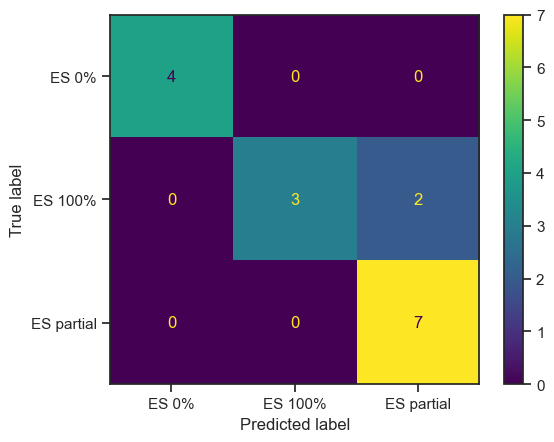

In [111]:
# display confusion matrix - MBL popn

cm = multilabel_confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
plt.show()

In [112]:
# breakdown of ES 100% false negatives
trues = conf_mtrx_df['ES_percent_true'] == 'ES 100%'
preds1 = conf_mtrx_df['ES_percent_pred'] == 'ES partial'
preds2 = conf_mtrx_df['ES_percent_pred'] == 'ES 0%'

ES_100_FNs = conf_mtrx_df[trues & (preds1 | preds2)]
ES_100_FNs



,pdfname,gt_source,nlp_path,language,similarity_th,cleanup_th,ES_percent_true,ES_percent_pred,num_cats_true,num_cats_pred,num_cats_diff,ES_partial_True_Positives
0,AES-Green-Financing-Framework-Reporting-May-2025,alloc data table,UOP_section_false,EN,0.97,0.77,ES 100%,ES partial,1,3,-2,False
15,Framework_ISA_CTEEP,alloc data table,UOP_section_true,PT,0.88,0.70,ES 100%,ES partial,1,3,-2,False


In [113]:
# breakdown of ES partials FNs
trues = conf_mtrx_df['ES_percent_true'] == 'ES partial'
preds = conf_mtrx_df['ES_percent_pred'] == 'ES 0%'

ES_partial_FNs = conf_mtrx_df[trues & preds]
ES_partial_FNs

,pdfname,gt_source,nlp_path,language,similarity_th,cleanup_th,ES_percent_true,ES_percent_pred,num_cats_true,num_cats_pred,num_cats_diff,ES_partial_True_Positives


In [114]:
# breakdown of ES partials TPs
trues = conf_mtrx_df['ES_percent_true'] == 'ES partial'
preds = conf_mtrx_df['ES_percent_pred'] == 'ES partial'

ES_partial_TPs = conf_mtrx_df[trues & preds]
ES_partial_TPs

,pdfname,gt_source,nlp_path,language,similarity_th,cleanup_th,ES_percent_true,ES_percent_pred,num_cats_true,num_cats_pred,num_cats_diff,ES_partial_True_Positives
4,Green_Bond_Framework,alloc data table,Table,EN,0.97,0.77,ES partial,ES partial,9,2,7,True
6,greenbondsprogramme,alloc data table,UOP_section_true,EN,0.97,0.77,ES partial,ES partial,4,4,0,True
10,FEFA_20V_Green_Bond_Framework,alloc data table,Table,EN,0.97,0.77,ES partial,ES partial,4,3,1,True
11,FEFA_Green_Bond_Framework,alloc data table,Table,EN,0.97,0.77,ES partial,ES partial,4,3,1,True
12,Green_Bonds_Framework_-_Banco_Pichincha,alloc data table,UOP_section_true,ES,0.80,0.65,ES partial,ES partial,7,6,1,True
13,Marco_de_la_Primera_Emision,alloc data table,Table,ES,0.80,0.65,ES partial,ES partial,2,4,-2,True
14,Marco_del_Bono_Verde,alloc data table,Table,ES,0.80,0.65,ES partial,ES partial,7,7,0,True


In [115]:
# breakdown other TPs to check cat count
trues0 = conf_mtrx_df['ES_percent_true'] == 'ES 0%'
preds0 = conf_mtrx_df['ES_percent_pred'] == 'ES 0%'
trues100 = conf_mtrx_df['ES_percent_true'] == 'ES 100%'
preds100 = conf_mtrx_df['ES_percent_pred'] == 'ES 100%'

ES_0_TPs = conf_mtrx_df[trues0 & preds0]
ES_0_TPs

,pdfname,gt_source,nlp_path,language,similarity_th,cleanup_th,ES_percent_true,ES_percent_pred,num_cats_true,num_cats_pred,num_cats_diff,ES_partial_True_Positives
3,"Framework,_Green_Bond_Protisa_Peru",alloc data table,Table,EN,0.97,0.77,ES 0%,ES 0%,3,1,2,False
5,Green_social_bond_framework_series_ab_ac_2018,alloc data table,Table,EN,0.97,0.77,ES 0%,ES 0%,2,2,0,False
7,Rumo_Green_Bond_2028_Framework,alloc data table,UOP_section_false,EN,0.97,0.77,ES 0%,ES 0%,2,3,-1,False
8,Sustainability_Bond_Framework,alloc data table,Table,EN,0.97,0.77,ES 0%,ES 0%,4,2,2,False


In [116]:
# breakdown other TPs - cat count must be 1 but check

ES_100_TPs = conf_mtrx_df[trues100 & preds100]
ES_100_TPs

,pdfname,gt_source,nlp_path,language,similarity_th,cleanup_th,ES_percent_true,ES_percent_pred,num_cats_true,num_cats_pred,num_cats_diff,ES_partial_True_Positives
1,BNDES_Green_Bond_Framework,alloc data table,UOP_section_true,EN,0.97,0.77,ES 100%,ES 100%,1,1,0,False
2,Climate_Bond_Framework_of_Athon_in_2021,alloc data table,UOP_section_true,EN,0.97,0.77,ES 100%,ES 100%,1,1,0,False
9,wcc-green-bond-second-party-opinion-05222019,alloc data table,Table,EN,0.97,0.77,ES 100%,ES 100%,1,1,0,False


In [117]:
# accuracy metrix - MBL popn

as_frac = round(accuracy_score(y_true, y_pred),2)
accuracy_score_num = accuracy_score(y_true, y_pred, normalize=False)
print(as_frac, accuracy_score_num)

ck = round(cohen_kappa_score(y_true, y_pred),2)
print(ck)

f1 = round(f1_score(y_true, y_pred, average='macro'),2)
print(f1)

0.88 14.0
0.8
0.88


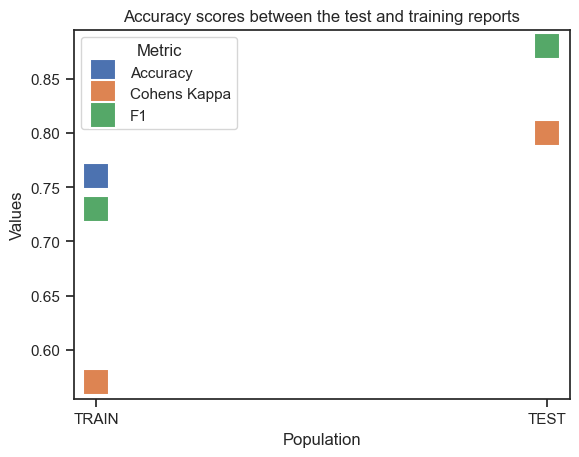

In [118]:
# line plot the accuracy results
#fig, ax = plt.subplots
accuracy_measures = {'Population': ['TRAIN', 'TRAIN','TRAIN', 'TEST', 'TEST', 'TEST'],
                    'Metric': ['Accuracy', 'Cohens Kappa' , 'F1' , 'Accuracy', 'Cohens Kappa' , 'F1'],
                    'Values': [0.76, 0.57, 0.73, as_frac, ck, f1]}
acc_meas_df = pd.DataFrame(accuracy_measures)
sns.set_theme(style='ticks')
#sns.set_style('whitegrid')
sns.scatterplot(data = acc_meas_df, x = 'Population', y = 'Values', hue= 'Metric', marker = 's', s=350)

plt.title('Accuracy scores between the test and training reports')
plt.show()


In [119]:
# create a dataset containing results for boxplots - MBL popn

boxplot_df = conf_mtrx_df.query("ES_partial_True_Positives == True")
boxplot_df.info()


<class 'pandas.DataFrame'>
Index: 7 entries, 4 to 14
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pdfname                    7 non-null      str    
 1   gt_source                  7 non-null      str    
 2   nlp_path                   7 non-null      str    
 3   language                   7 non-null      str    
 4   similarity_th              7 non-null      float64
 5   cleanup_th                 7 non-null      float64
 6   ES_percent_true            7 non-null      str    
 7   ES_percent_pred            7 non-null      str    
 8   num_cats_true              7 non-null      int64  
 9   num_cats_pred              7 non-null      int64  
 10  num_cats_diff              7 non-null      int64  
 11  ES_partial_True_Positives  7 non-null      bool   
dtypes: bool(1), float64(2), int64(3), str(6)
memory usage: 1.2 KB


Standard deviation of diff in number of categories is 2.7945525240230884


<Axes: xlabel='num_cats_diff', ylabel='nlp_path'>

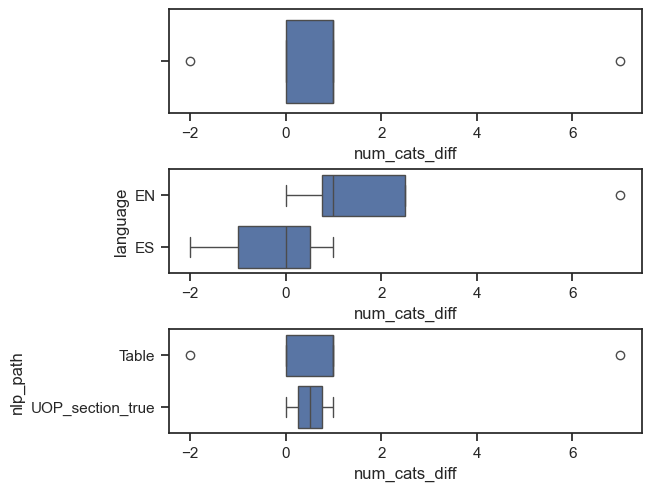

In [120]:
# boxplots of diff in number of cats - MBL popn
std = boxplot_df.describe().loc['std', 'num_cats_diff']
print(f'Standard deviation of diff in number of categories is {std}')
fig, axes = plt.subplots(3,1, layout = 'constrained')
sns.set_theme(style='ticks', palette = 'pastel')
sns.boxplot(x=boxplot_df['num_cats_diff'], ax=axes[0])
sns.boxplot(x=boxplot_df['num_cats_diff'], y = boxplot_df['language'], ax=axes[1])
sns.boxplot(x=boxplot_df['num_cats_diff'], y = boxplot_df['nlp_path'], ax=axes[2])
